<a href="https://colab.research.google.com/github/Alissa-Ouspen/data201_alissa/blob/main/week4/wk4_log_reg_assign_Alissa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alissa  -  Assignment – Week 4  
## Logistic Regression: R → Python Bridge

**Course:** Data Science  
**Submission:** Jupyter Notebook (.ipynb)  
**Dataset:** `housing.csv`

---

# Learning Objectives

By the end of this assignment, you should be able to:

- Fit and interpret **logistic regression models**
- Translate workflows from **R (glm / tidymodels)** to **Python**
- Interpret **odds ratios**
- Evaluate classification models using **Accuracy and ROC–AUC**
- Reflect on the difference between **statistical inference vs prediction**

---

# Dataset Description

The dataset contains **600 housing listings**.

| Variable | Description |
|---|---|
| listing_id | Unique identifier |
| price | Sale price of the house |
| size | House size (square footage) |
| bedrooms | Number of bedrooms |
| neighborhood | Location category |
| type | Housing type (SingleFamily, Townhouse, MultiFamily) |

---

# Step 0 – Create a Binary Outcome

For classification, convert price into a binary variable.

```
high_price = price > median(price)
```

This creates two groups:

- `1` → expensive homes  
- `0` → less expensive homes  

---



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay, RocCurveDisplay

In [46]:
# Load the dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")

# Create the boolean outcome high_price
df["high_price"] = np.where(df["price"] > df["price"].median(), 1, 0)
# = np.where(df["price"] > np.median(df["price"]), 1, 0)

print(f"Median = {np.median(df["price"])}")
df.head()  # print(df["price"].median())

Median = 201165.0


,listing_id,price,size,bedrooms,neighborhood,type,high_price
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0


---

# Part A – Logistic Regression for Inference


### Report

Create a table including:

- coefficients
- odds ratios
- p-values

In [3]:
# Fit a logistic regression using statsmodels
model_sm = smf.logit(
    "high_price ~ size + bedrooms + C(neighborhood)",
    data = df
).fit()

print(model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.684990
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      517
Method:                           MLE   Df Model:                            6
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                 0.01177
Time:                        22:18:50   Log-Likelihood:                -358.93
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.2006
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.3796      0.289      1.311      0.

In [4]:
odds_ratios = model_sm.params.apply(np.exp)
odds_ratios

,0
Intercept,1.461647
C(neighborhood)[T.Midtown],0.736015
C(neighborhood)[T.Suburb],1.113030
C(neighborhood)[T.Uptown],1.048173
C(neighborhood)[T.Waterfront],1.511416
size,0.999479
bedrooms,1.261433


### Short Analysis
The size of the house is significantly (p = 0.037) correlated with whether the house is categorized as "expensive".  
This is significant at the α = 0.05 level.  
However, the Pearson's correlation coefficient for the "size" variable is -0.005, which means there is no linear relationship between size and price.  
There could be a significant but non-linear relationships between the variables which the logistic regression does not test for.  Since the sample size is very large (524), this could help explain the significance of that relationship.    

The Waterfront neighborhood has the higher odds ratio of expensive homes (1.51).  
This means the odds that an expensive home is on the Waterfront are approximately 0.6, while the odds it is in Downtown (the reference variable) is 0.4.  So, the odds that an expensive home is on the Waterfront is 1.5 times higher than the odds it is in Downtown.  

    
odds ratio =  $e^\beta$  
  

log (odds ratio) = $\beta_1$  = $log\frac{odds(Y=1|x=1)}{odds(Y=1|x=0)}$  
  
  
log odds = logit =  $log(\frac{p}{1-p})$ = $log\frac{odds(Y=1)}{odds(Y=0)}$

-----------------    

# Part B – Interpretation

For every additional bedroom, the odds of a house being expensive increase by 0.2614, or 26.14%.

Odds(size) = 0.9995.  Increase of .9995 = decrease of .0005.  

For every additional square foot of size, the odds of a house being expensive decrease by 0.0005, or 0.05%.



---


  


# Part C – Prediction Workflow  
## (tidymodels → scikit-learn)

### 1. Train/Test Split

Split the data:

- 80% training
- 20% testing

In [47]:
# must drop NaN (although get_dummies handles NaNs in categorical columns by default, it's good practice for numerical features or if explicitly needed)
df_cleaned = df.dropna(subset = ["bedrooms", "size"])

# (get_dummies handles NaNs in categorical columns by default)

# create df with reference variables, k-1 classes
df_encoded = pd.get_dummies(
    df_cleaned, columns = ["neighborhood", "type"], drop_first = True)

# Create X and y
# X should contain all feature columns, excluding the target and original identifiers
X = df_encoded.drop(columns = ["listing_id", "price", "high_price"])
y = df_encoded["high_price"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
     X, y, test_size = 0.2, random_state = 42)  #test size is 20%

------
### 2. Fit Logistic Regression
----------

In [48]:
# Fit a logistic regression model
model_sk = LogisticRegression(max_iter = 1000) # number of times run simulation
model_sk.fit(X_train, y_train)  # Must drop NaNs!

LogisticRegression(max_iter=1000)

In [15]:
# Generate class predictions and predicted probabilities
y_pred = model_sk.predict(X_test)
print(f"predictions = \n { y_pred} \n")  # bool values

y_prob = model_sk.predict_proba(X_test)[:, 1] # Select prob of Class y = 1

print(f"probabilities of y = 1: \n { np.round(y_prob, 2)}") # float values

predictions = 
 [1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 0 1 0 0 1 1 0 1 1 0 1 1 1 0 0 0 0
 0 1 1 0 1 0 0 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 1 0 1 1 0 1 0 1 1 0
 1 0 1 1 1 1 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 0] 

probabilities of y = 1: 
 [0.52 0.62 0.57 0.45 0.66 0.61 0.52 0.61 0.61 0.55 0.55 0.57 0.54 0.55
 0.46 0.59 0.41 0.49 0.58 0.53 0.42 0.55 0.44 0.49 0.58 0.53 0.41 0.56
 0.5  0.47 0.58 0.62 0.53 0.44 0.42 0.4  0.36 0.41 0.58 0.56 0.47 0.53
 0.48 0.49 0.37 0.53 0.6  0.41 0.54 0.52 0.45 0.5  0.6  0.68 0.33 0.51
 0.61 0.56 0.54 0.45 0.52 0.54 0.38 0.39 0.63 0.47 0.53 0.54 0.38 0.55
 0.39 0.65 0.52 0.41 0.62 0.45 0.63 0.58 0.65 0.53 0.47 0.48 0.49 0.34
 0.39 0.53 0.54 0.52 0.62 0.61 0.56 0.56 0.38 0.51 0.53 0.65 0.5  0.67
 0.53 0.59 0.4  0.53 0.62 0.55 0.44]



### 3. Evaluate the Model

Report:

- **Accuracy**
- **ROC–AUC**

In [32]:
# Compute accuracy
accuracy = accuracy_score(y_test, y_pred)  #y_test = y_true
print(f"Accuracy Score: {accuracy: .4}")

Accuracy Score:  0.4667


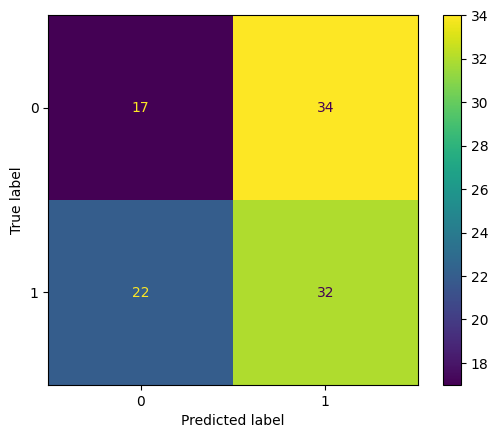

In [17]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
#          [[correct, wrong],
#          [wrong, correct]]

cm_display = ConfusionMatrixDisplay(cm).plot()

In [30]:
# compute y_score for AUC and ROC curve
y_score = model_sk.decision_function(X_test)

# compute AUC (Area under the curve)
auc = roc_auc_score(y_test, y_score)
print(f"AUC Score: {auc: .4}")

AUC Score:  0.4394


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


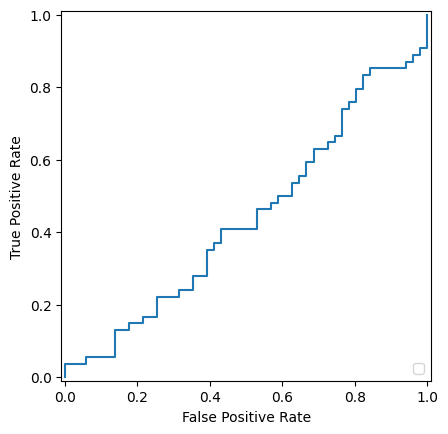

In [29]:
# get true pos rate (true pos to all pos)
#  & false pos rate (false pos to all negs)
fpr, tpr, _ = roc_curve(
    y_test, y_score, pos_label = model_sk.classes_[1])

# plot ROC curve (Receiver operating characteristic)
roc_display = RocCurveDisplay(fpr = fpr, tpr = tpr).plot()


----
# Part D – Model Understanding

### Accuracy vs AUC

Why might **ROC–AUC** sometimes be preferred over **accuracy**?
Why might ROC–AUC sometimes be preferred over accuracy

Explain in **2–3 sentences**.

*Accuracy is the ratio of all correct predictions to all incorrect predictions. It usually measures performance at the 0.5 threshold.  
This makes it less flexible, if a different threshold is necessary in a different context.*

*The Receiver Operating Characteristic (ROC) evaluates model performance at various classification thresholds, making it more flexible.  
It compares the True Positive Rate and False Positive Rate and takes into account how changes in the threshold affect both true and false positives.   
Since it looks more closely at classification, it provides more information for improving algorithms.*

*The AUC is the area under the ROC curve.*  

*The ROC and AUC are useful when class sizes are very different, because the curve balances the class sizes and deals with skewed distributions.   
They are also preferred when the costs of false positives and false negatives differ greatly.*

-----------

-------------

Which modeling approach would you choose for:

- **Policy analysis**
- **Prediction tasks**

*For prediction tasks, I would choose the Accuracy approach, because I would only be interested in correct and incorrect preditions:  I would not need the predictions to be weighted.*  

*I would use the ROC-AUC for policy decisions, because skewing could have a great impact on the population to whom the policy would apply.  Decisions would need to be made as to whether to adjust the assessment, depending on the costs associated with false positives or false negatives.  In different contexts, one is more costly than the other.*

---

---

# Part E – Explore the Dataset

Before modeling, briefly explore the data.

Create **at least three plots** such as:

- Histogram of `price`
- Scatter plot: `size` vs `price`
- Boxplot: `price` by `neighborhood`
- Bar chart: housing `type`

Discuss **one interesting pattern** you observe.

*The distribution looks normally distributed, with mean and median nearly equal.  
There are no visible differences in price by neighborhood (boxplot) nor by  
type of home (bar chart), and there seems to be no correlation between size and price.*

---

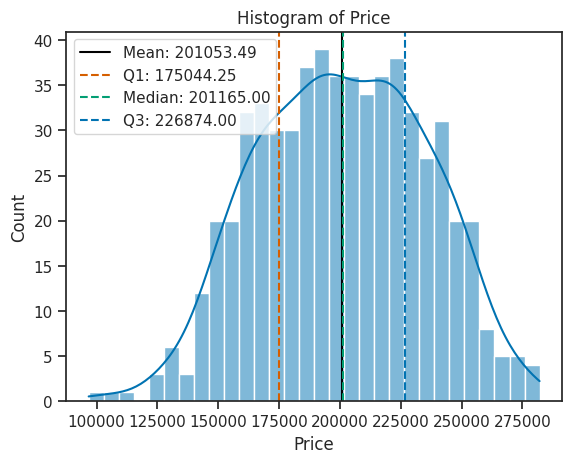

In [52]:
# Histogram of price
sns.histplot(data = df, x = "price", kde = True, bins = 30)

mean = (df["price"].mean())
plt.axvline(
    mean, color = "black", linestyle = "solid", label = f"Mean: {mean:.2f}")

# quantiles
q25 = df["price"].quantile(0.25)
q50 = df["price"].quantile(0.50) # Median
q75 = df["price"].quantile(0.75)

# Add vertical lines for quantiles
plt.axvline(q25, color = "r", linestyle = "--", label = f"Q1: {q25:.2f}")
plt.axvline(q50, color = "g", linestyle = "--", label = f"Median: {q50:.2f}")
plt.axvline(q75, color = "b", linestyle = "--", label = f"Q3: {q75:.2f}")

plt.title("Histogram of Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.legend()
plt.show()

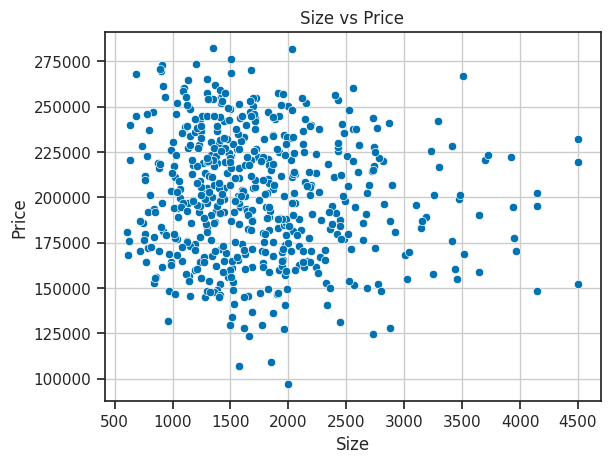

In [34]:
sns.set_theme(style = "ticks", palette = "colorblind")
sns.scatterplot(
    data = df, x = "size", y = "price")
plt.title("Size vs Price")
plt.xlabel("Size")
plt.ylabel("Price")
plt.grid()
plt.show()

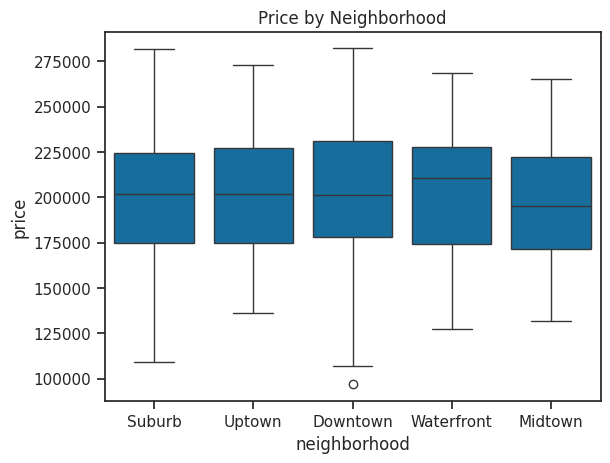

In [35]:
sns.boxplot(data = df, x = "neighborhood", y = "price")
plt.title("Price by Neighborhood")
plt.show()

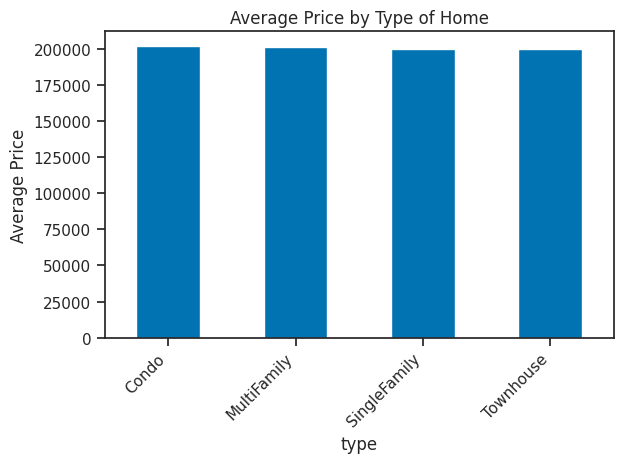

In [50]:
# mean price for each housing type
mean_price_by_type = df.groupby("type")["price"].mean().reset_index()

# bar chart with mean prices
ax = mean_price_by_type.plot.bar(x = "type", y = "price", legend = False)
plt.title("Average Price by Type of Home")
plt.ylabel("Average Price")
plt.xticks(rotation = 45, ha = "right") # Rotate labels for better readability
plt.tight_layout() # so labels don't get cut off
plt.show()

In [44]:
print(mean_price_by_type)
print(df["price"].mean())

           type          price
0         Condo  202232.622951
1   MultiFamily  201539.460317
2  SingleFamily  200413.353191
3     Townhouse  200247.050420
201053.48833333334
